# Visualizing Social Vulnerability in Counties Affected by Hurricane Helene

```{image} ../thumbnails/U.S._Census_Bureau_logo_post-2011.svg.png
:alt: US Census Bureau logo
:width: 200px
```

---

## Overview

46.5% of the counties affected by Hurricane Helene had higher-than-average social vulnerability estimates, compared to the national percentage of 30.1% of counties with higher-than-average social vulnerability estimates (Sawyer, 2025). Higher-than-average percentages of people living in rural areas compared to the national average were also seen in the affected counties, leading to increased difficulties for recovery efforts post-storm (Sawyer, 2025). Other socioeconomic vulnerabilities, such as poverty levels, also impacted the aftermath of Hurricane Helene. 

---

## Import Packages

In [1]:
import matplotlib.pyplot as plt
from mapclassify import UserDefined
import geopandas as gpd
from shapely import wkt
import pandas as pd
from cartopy import crs as ccrs
from cartopy import feature as cfeature
from metpy.plots import USCOUNTIES

---

## Import CSV Data as a Pandas DataFrame

In notebook1, we merged two dataframes: the [**Census Bureau’s Assessment, Recovery, and Evaluation datasets or CAREs**](https://www.census.gov/programs-surveys/community-resilience-estimates/projects/disaster-recovery/hurricane-helene.html) dataset from the US Census Bureau and the [**GeoPandas’ built-in TIGER/Cartographic Boundary files**](https://www2.census.gov/geo/tiger/GENZ2022) from the U.S. Census Bureau. The merging of these two datasets created a new CSV file called helene_merged.csv, which includes population, exposure, and recovery data for Hurricane Helene, as well as the polygon geometry of the counties. We will now import the helene_merged.csv as a Pandas DataFrame.

In [2]:
helene_merged = pd.read_csv('../data/helene_merged.csv')

The county geometry column in helene_merged was stored as a WKT string so it needs to be converted to a Shapely geometry format in order for GeoPandas to be able to recognize it as a polygon

In [3]:
helene_merged['geometry'] = helene_merged['geometry'].apply(wkt.loads)

Now that the geometry column has been properly converted, we can convert helene_merged to a GeoDataFrame, allowing us to plot the polygons. We will also ensure that the geometries are in the same coordinate reference system (CRS) as the map we are using.

In [4]:
helene_merged = gpd.GeoDataFrame(helene_merged, geometry='geometry', crs="EPSG:4326")

Recall that this dataset includes the 299 counties which issued Presidential Disaster Declarations as a result of Hurricane Helene. We will now visualize some social vulnerability parameters such as povery level percentages, social vulnerability levels, and rurality percentages. 

---

## Visualizing Poverty Level Percentages

The SAEPOVRTALL_PT_23 column from the DataFrame tells us the rate estimate of all ages in poverty over the counties which issues a Presidential Disaster Declaration. Using .describe() lets us see some statistics from the column. States such as Kentucky had higher poverty rates compared to the national average of 12.5% (Sawyer, 2025). Overall, the poverty rate of counties that issued a declaration was slightly higher than the national average at 13.6%.

In [5]:
#summary stats (min, max, mean, etc.)
print(helene_merged['SAEPOVRTALL_PT_23'].describe())

count    299.000000
mean      17.419064
std        5.696956
min        6.300000
25%       13.350000
50%       16.800000
75%       21.400000
max       37.200000
Name: SAEPOVRTALL_PT_23, dtype: float64


Now that we have an idea of the contents of the column, lets see the distribution of the poverty levels geographically.

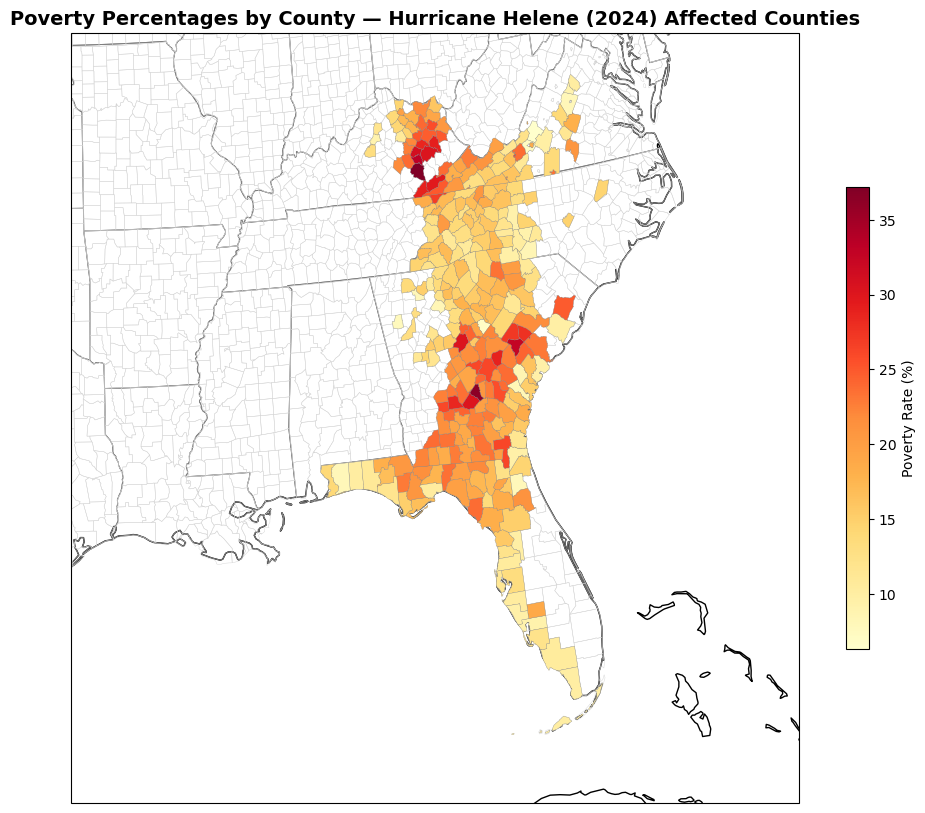

In [6]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='SAEPOVRTALL_PT_23',      
    cmap='YlOrRd',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Poverty Rate (%)", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Poverty Percentages by County — Hurricane Helene (2024) Affected Counties', fontsize=14, weight='bold')

plt.show()

---

## Visualizing Rurality

Let's see how this spatial distribution of poverty compares to the spatial distribution of rurality. We can use the column RURAL_POP_DEC_2020 to see the number of people living in rural areas as recorded by the 2020 U.S. Census. Counties with notable rural populations were among the many counties that issued a presidential disaster declaration, with 28% of residents in impacted counties living in rural areas compared to the 20% seen nationally (Sawyer, 2025).

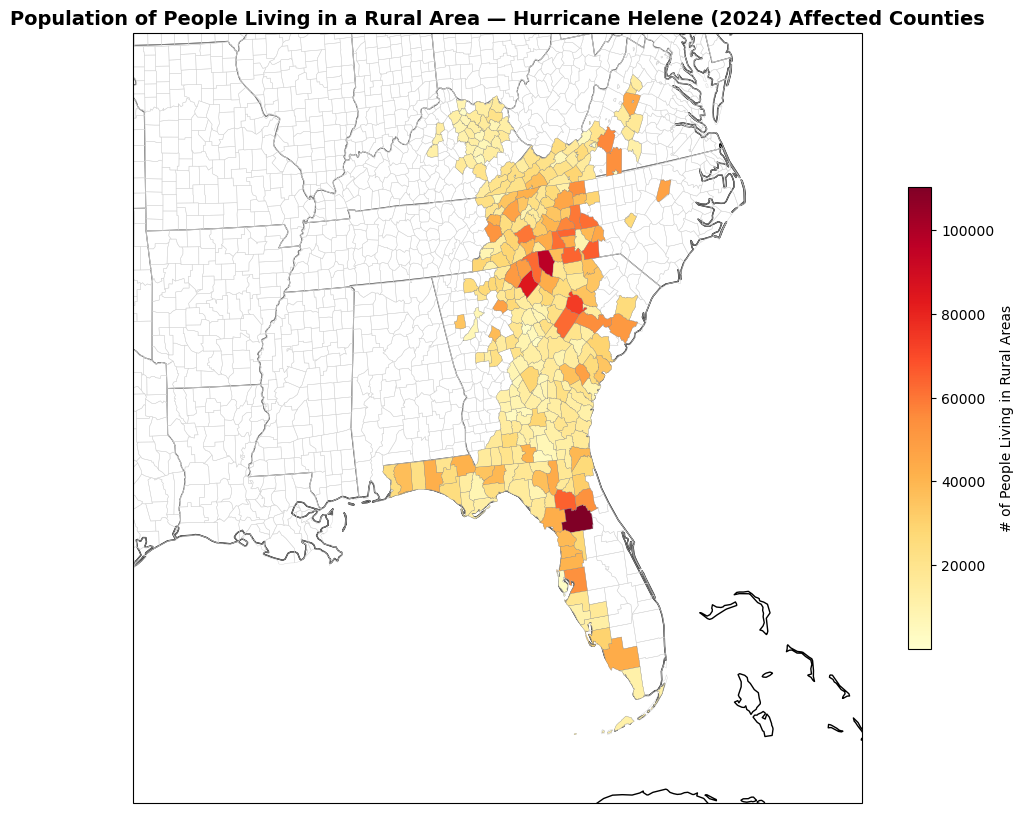

In [7]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='RURAL_POP_DEC_2020',      
    cmap='YlOrRd',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "# of People Living in Rural Areas", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Population of People Living in a Rural Area — Hurricane Helene (2024) Affected Counties', fontsize=14, weight='bold')

plt.show()

---

## Visualizing Age Distribution

By looking at the estimated age dependency ratio, DEP_Ratio_E_23, we can get a better idea of the distribution of the ratio of dependents (under 15 or over 64) to the working-age population (15-64). Age distribution is a major factor when considering social vulnerability in the counties impacted by Hurricane Helene.

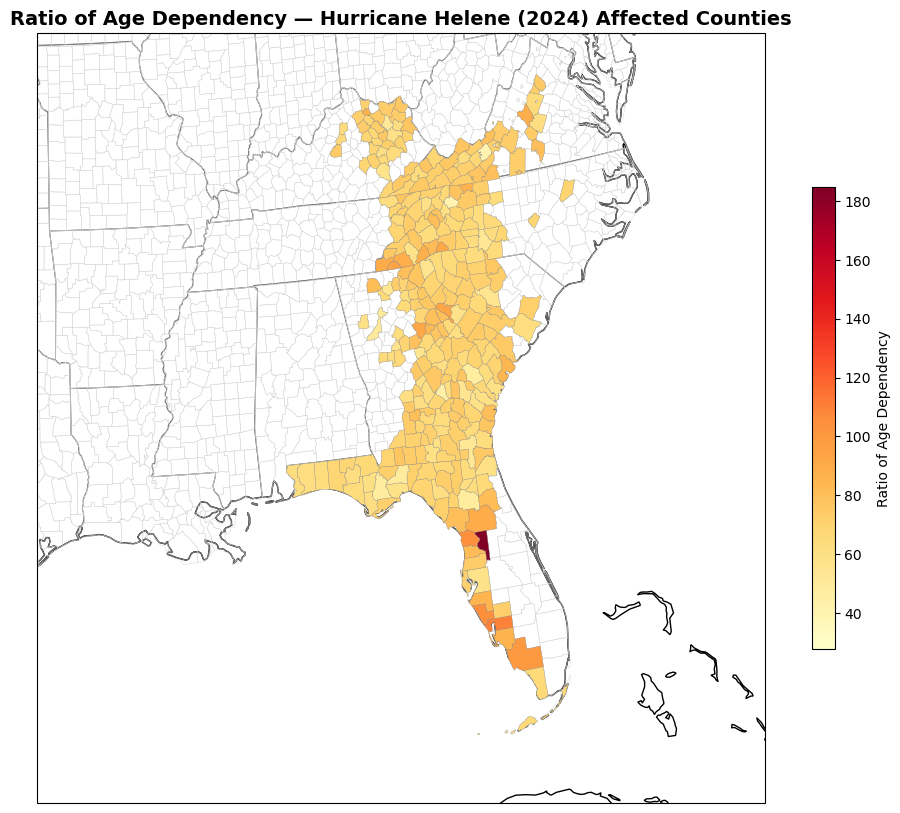

In [8]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='DEP_Ratio_E_23',      
    cmap='YlOrRd',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Ratio of Age Dependency", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Ratio of Age Dependency — Hurricane Helene (2024) Affected Counties', fontsize=14, weight='bold')

plt.show()

Each of these variables provide necessary context to the vulnerability of the populations affected by Hurricane Helene and the extent of the damage and recovery process. We can further examine the social vulnerability parameters of the counties impacted by Hurricane Helene in the following section.

---

## Visualizing Social Vulnerbility Parameters

This dataset includes precalculated social vulnerability values. We can examine variables PCT3_23 and PCT3_ST_23 to visualize the ranking of geographies by percent with three or more components of social vulnerability and the ranking of geographies within a state by percent with three or more components of social vulnerability, respectively. These variables are a byproduct of the US Census Bureau's Community Resilience Estimates (CRE). The CRE determines the community's ability to reconcile with the impacts of a disaster by analyzing ten components of social vulnerability, such as income-to-poverty ratio, disability, communication barriers, etc (Sawyer, 2025). Individuals with three or more of these components are then placed into the high vulnerability group (Sawyer, 2025).

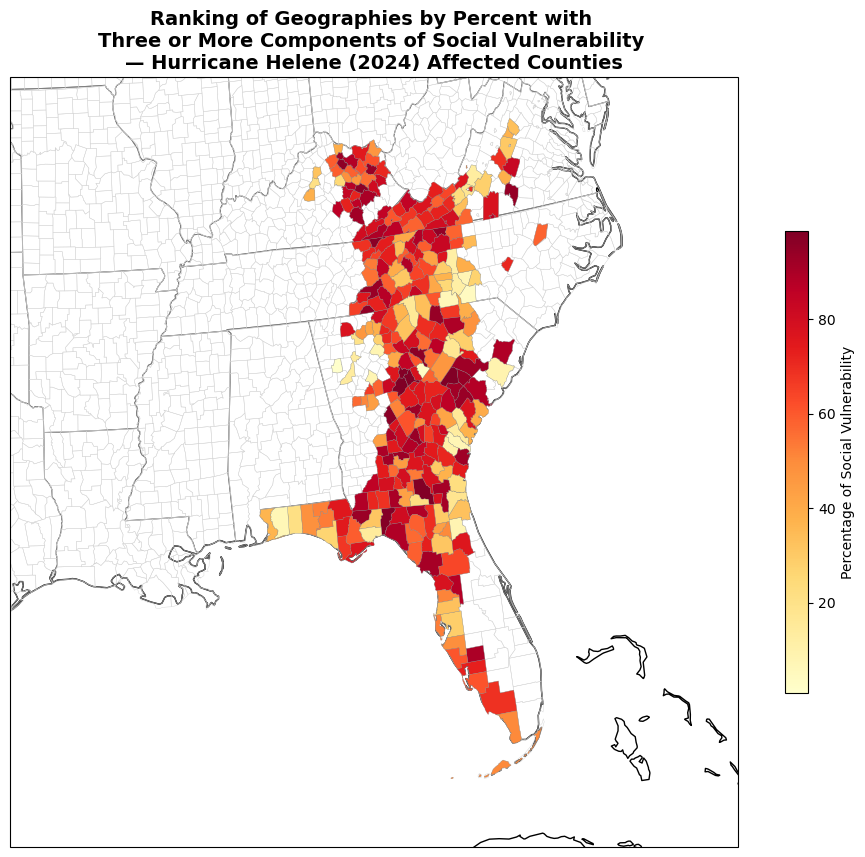

In [13]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='PCT3_23',      
    cmap='YlOrRd',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Percentile of Social Vulnerability", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Ranking of Geographies by Percent with \nThree or More Components of Social Vulnerability \n— Hurricane Helene (2024) Affected Counties', fontsize=14, weight='bold')

plt.show()

Next, we can look at the ranking of counties within a state by percent with three or more components of social vulnerability. This allows us to see how social vulnerability rankings are based on the national or state level. We'll follow a similar plotting scheme as our map above.

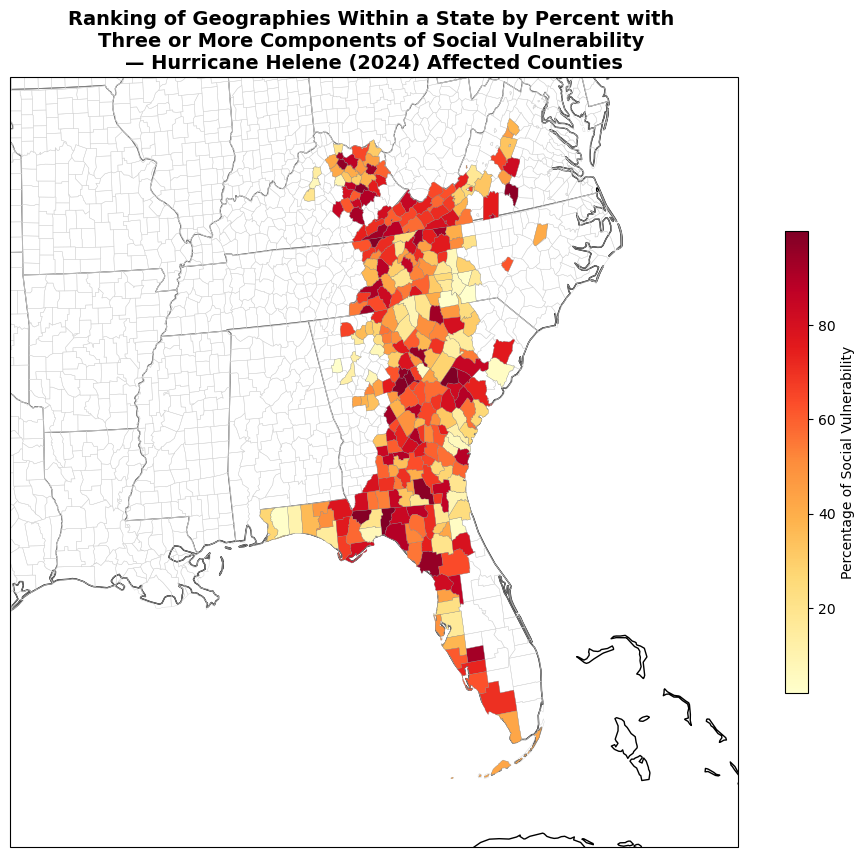

In [14]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='PCT3_ST_23',      
    cmap='YlOrRd',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Percentile of Social Vulnerability", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Ranking of Geographies Within a State by Percent with \nThree or More Components of Social Vulnerability \n— Hurricane Helene (2024) Affected Counties', fontsize=14, weight='bold')

plt.show()

We can also look at social vulnerability in the context of specific diasters. The HRCN_PCT3_23 variable tells us the ranking of counties by percent with three or more components of social vulnerability that are considered to have "Relatively Moderate" hurricane risk or higher based on FEMA's National Risk Index. 

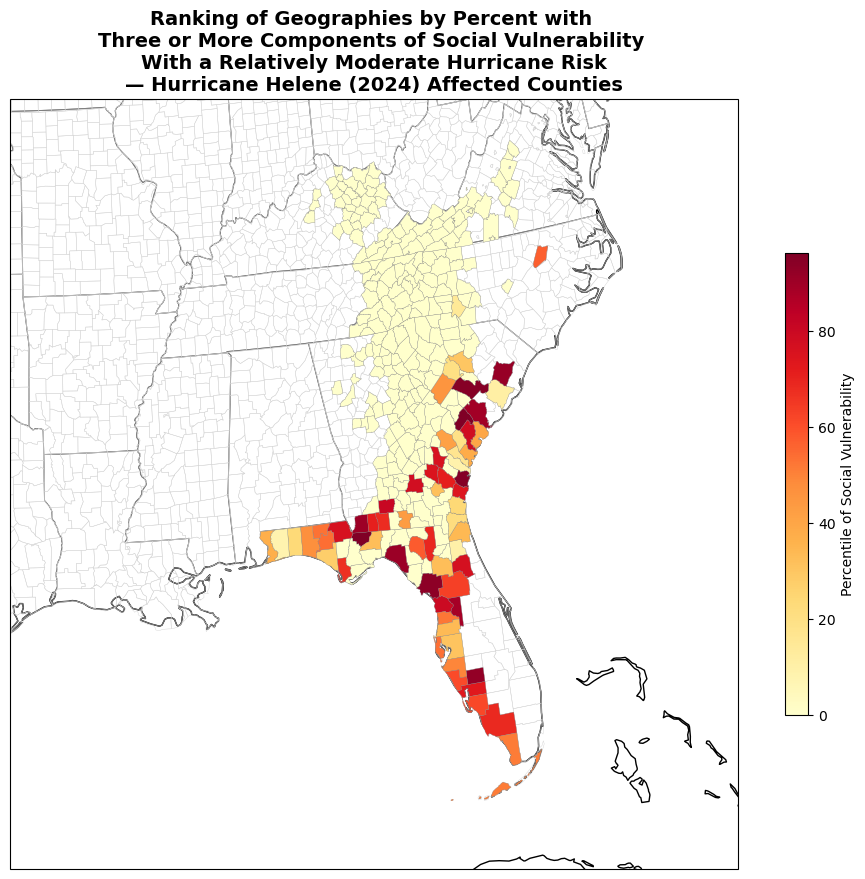

In [12]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='HRCN_PCT3_23',      
    cmap='YlOrRd',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Percentile of Social Vulnerability", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Ranking of Geographies by Percent with \nThree or More Components of Social Vulnerability \nWith a Relatively Moderate Hurricane Risk\n— Hurricane Helene (2024) Affected Counties', fontsize=14, weight='bold')

plt.show()

We can see a wide distribution of socially vulnerable counties across the states impacted by Hurricane Helene. When considering the map that takes into account hurricane risk, the impacts seen by Hurricane Helene challenge the pre-existing FEMA Risk Index, which suggests higher risks for coastal counties. While disasters like Helene are rare for inland counties, these maps show that when disaster impacts socially vulnerable counties, the impacts are widespread and the recovery process is extensive due to these preexisting factors.

---

## Summary

This notebook read in the helene_merged.csv we created in notebook1, but we also had to ensure that the geometry column was readable. We converted the MKT String to Shapely Geometry to convert helene_merged to a GeoDataFrame so the geometry column could be read as polygons. After that, this notebook plotted poverty level percentages using data from helene_merged, as well as the number of people living in rural areas and the age dependency ratio in the counties where Hurricane Helene led to a presidential disaster declaration. Following that section, this notebook looked at the spatial distribution of social vulnerability parameters and how that varied nationally, at the state level, and when considering hurricane risk as another factor. 

---

## What's Next?

Following this notebook, this cookbook will be concluded, bringing together the different topics discussed in each section to provide a comprehensive look at Hurricane Helene.